<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Gradient_Saliency_by_Hand.ipynb)

# Gradient Saliency, by Hand
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

**`Univariate_Temperature_RNN_pt2`** asked *what is the model looking at?* by **occlusion**: blank one day of the
window and see how much the forecast moves. That is a real experiment, and it costs one re-scoring per day.

This notebook asks the same question with calculus, on the **same saved LSTM** - and then does the thing most
tutorials skip: it **checks whether the answer is true**.

$$
\text{saliency of day } k \;=\; \frac{\partial \hat{y}}{\partial x_k} \;\approx\;
\frac{\text{change in forecast}}{+1 \text{ °C on day } k}
$$

A gradient is a **promise about an experiment nobody ran**: *"add one degree to day $k$ and my forecast moves by
this much."* It is computed from the model's slope at one exact point, so it is only a *local* approximation - and
nothing in TensorFlow tells you how local. So we make it keep the promise:

| | the question | the cost |
| :-- | :-- | :-- |
| **A. One window** | where is this forecast sensitive, and in which direction? | one gradient pass |
| **B. The promise** | add a real +1 °C - did the forecast move the way the gradient said? | ten re-scorings |
| **C. All windows** | is "yesterday dominates" the rule, or just the average? | one gradient pass |

Inference only: nothing is trained here, and the whole notebook runs in about a minute.

*Multivariate saliency (a sensors × minutes grid), integrated gradients, what-if and SHAP live in
**`Explaining_an_LSTM`**.*

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 19b — Gradient saliency, and how to check that it isn't lying to you
- Recap in one line: occlusion HIDES a day, saliency NUDGES it. Same question, different cost.
- Panel A: one real window, February 1990. Signed gradients, not absolute - green pushes the forecast up, red pushes it down. Yesterday is +0.61 C per +1 C and the other nine days combined only reach 0.49.
- Panel B is the one that matters, and it's the part tutorials skip. A gradient is a promise about an experiment nobody ran. So run it: add a real +1 C to day k in every test window and measure. Largest disagreement 0.0105 C - dead on the 45 degree line, so you're allowed to read the bars as degrees.
- Say what a FAILURE would look like: points off the line means the model is non-linear over that range and the gradient is only true for infinitesimal nudges. Then occlusion - the real experiment - is the one to trust.
- Panel C: one window is an anecdote. The heatmap is all 364. Yesterday is the top day in 100% of windows and carries 54% of the total gradient - and look at the summer band where day -3 and -4 light up too.
- Close on the trade-off: saliency is ONE gradient pass instead of ten re-scorings, which is why it's the one people use on big models - but only after you've checked it once the way we just did.
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from urllib.request import urlretrieve
from sklearn.metrics import mean_absolute_error
from keras.models import load_model
import keras
keras.utils.set_random_seed(5509)

## Rebuild the windows and download the model

Same file, same `split_sequence`, same look-back of 10, same 90/10 chronological split as Part 1 - so the test set here is the same one you occluded.

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/daily-min-temperatures.csv")

def split_sequence(sequence, n_steps):
    X, y = [], []
    for i in range(len(sequence)):
        end_ix = i + n_steps
        if end_ix > len(sequence) - 1: break
        X.append(sequence[i:end_ix]); y.append(sequence[end_ix])
    return np.array(X), np.array(y)

n_steps = 10
X, y = split_sequence(df["Temp"].values, n_steps)
X = X.reshape(X.shape[0], n_steps, 1)
cut = int(0.9 * len(X))
X_train, X_test, y_train, y_test = X[:cut], X[cut:], y[:cut], y[cut:]
days_ago = np.arange(n_steps, 0, -1)          # 10, 9, ... 1: the x-axis for every plot below

dates = pd.to_datetime(df["Date"])
test_dates = dates.iloc[n_steps + cut : n_steps + cut + len(y_test)]
print("test windows:", X_test.shape)

test windows: (364, 10, 1)


In [3]:
urlretrieve("https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/models/Univariate_Temperature_RNN.keras", "Univariate_Temperature_RNN.keras")
model = load_model("Univariate_Temperature_RNN.keras")

pred = model.predict(X_test, verbose=0).ravel()
base_mae = mean_absolute_error(y_test, pred)
print(f"reloaded LSTM test MAE: {base_mae:.2f} C   (Part 1 and Part 2 both reported 1.76)")

reloaded LSTM test MAE: 1.76 C   (Part 1 and Part 2 both reported 1.76)


## The gradient, in one function

`GradientTape` records what the model does to the inputs, then hands back $\partial \hat{y} / \partial x$ for
**every day of every window** in a single backward pass. It's the same machinery training uses - except training
points the derivative at the *weights*, and here we point it at the *inputs*.

In [4]:
def saliency(model, X):
    x = tf.convert_to_tensor(X, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x)                        # inputs aren't trainable, so we have to ask for them explicitly
        out = model(x, training=False)
    return tape.gradient(out, x).numpy()     # same shape as X: (windows, days, features)

G = saliency(model, X_test)[:, :, 0]         # (windows, 10) signed gradients
print("gradients:", G.shape, "-> one number per day, per window")

gradients: (364, 10) -> one number per day, per window


## A. One window, with the sign kept

The forecast for **February 16, 1990** - the same window the occlusion example used in Part 2. Top: the ten days the
model actually read. Bottom: the gradient for each day, **green pushes the forecast up, red pushes it down**.

Most of the bar chart is flat, and one bar isn't.

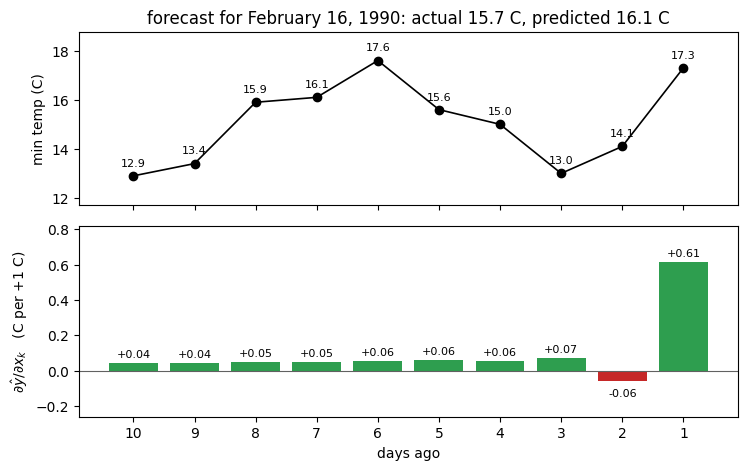

yesterday's gradient: +0.614 C per +1 C
the other nine days COMBINED: 0.489 C per +1 C (absolute values)
-> yesterday alone outweighs the other nine days put together


In [5]:
k = int(np.where(test_dates.dt.strftime("%Y-%m-%d") == "1990-02-16")[0][0])   # find it by date, don't hard-code it
g_one, w_one = G[k], X_test[k].ravel()

fig, ax = plt.subplots(2, 1, figsize=(8.5, 5), sharex=True,
                       gridspec_kw={"height_ratios": [1, 1.1], "hspace": 0.12})
ax[0].plot(days_ago, w_one, marker="o", color="black", lw=1.2)
for d, v in zip(days_ago, w_one):
    ax[0].annotate(f"{v:.1f}", (d, v), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
ax[0].set_ylabel("min temp (C)"); ax[0].margins(y=0.25)
ax[0].set_title(f"forecast for {test_dates.iloc[k]:%B %d, %Y}: "
                f"actual {y_test[k]:.1f} C, predicted {pred[k]:.1f} C")
ax[1].bar(days_ago, g_one, color=["#2E9E4F" if v >= 0 else "#C62828" for v in g_one])
ax[1].axhline(0, color="#616161", lw=0.8)
for d, v in zip(days_ago, g_one):
    ax[1].annotate(f"{v:+.2f}", (d, v), textcoords="offset points", xytext=(0, 4 if v >= 0 else -11),
                   ha="center", fontsize=8)
ax[1].invert_xaxis(); ax[1].set_xticks(days_ago); ax[1].margins(y=0.3)
ax[1].set_xlabel("days ago"); ax[1].set_ylabel(r"$\partial \hat{y} / \partial x_k$   (C per +1 C)")
plt.show()

print(f"yesterday's gradient: {g_one[-1]:+.3f} C per +1 C")
print(f"the other nine days COMBINED: {np.abs(g_one[:-1]).sum():.3f} C per +1 C (absolute values)")
print("-> yesterday alone outweighs the other nine days put together")

## B. Does the gradient keep its promise?

Now the experiment the gradient was predicting. For each day we add a real **+1 °C** to that day in **every** test
window and measure what the forecast actually did.

- **On the 45° line** - the gradient told the truth, and you can read panel A in degrees.
- **Off the line** - the model is non-linear over that range, the gradient is only true for infinitesimally small
  nudges, and **occlusion is the one to trust** because it is a real measurement rather than a slope.

This is the cell that turns saliency from a pretty picture into evidence.

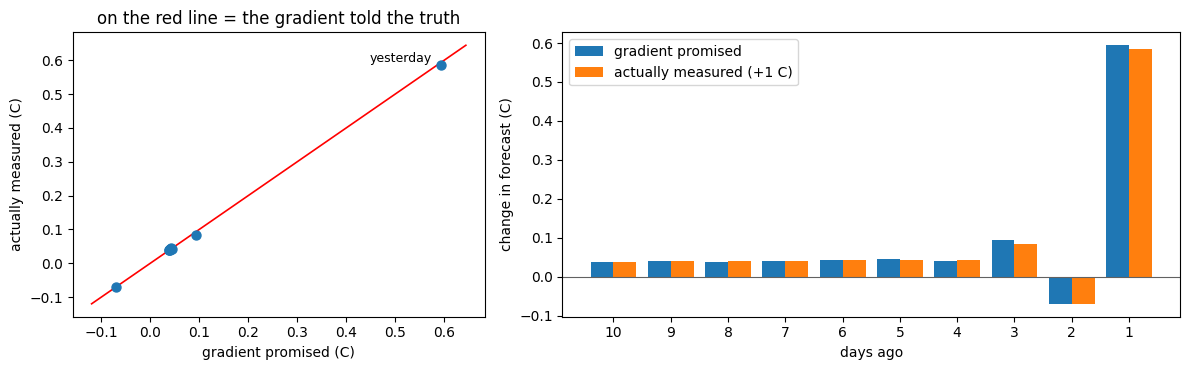

largest disagreement between promise and reality: 0.0105 C


,gradient promised,actually measured,gap
days ago,,,
10,0.038,0.038,0.000
9,0.040,0.041,0.001
8,0.038,0.039,0.002
7,0.040,0.041,0.001
6,0.043,0.044,0.001
5,0.045,0.043,-0.002
4,0.041,0.042,0.001
3,0.093,0.083,-0.010
2,-0.070,-0.070,-0.000


In [6]:
rows = []
for t in range(n_steps):
    Xb = X_test.copy(); Xb[:, t, 0] += 1.0                                  # a real +1 C on that day
    measured = (model.predict(Xb, verbose=0).ravel() - pred).mean()         # what the forecast actually did
    rows.append({"days ago": int(days_ago[t]), "gradient promised": G[:, t].mean(), "actually measured": measured})
promise = pd.DataFrame(rows).set_index("days ago")
promise["gap"] = promise["actually measured"] - promise["gradient promised"]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1, 1.5]})
lim = [promise.iloc[:, :2].values.min() - 0.05, promise.iloc[:, :2].values.max() + 0.05]
ax[0].plot(lim, lim, color="red", lw=1.2, zorder=1)
ax[0].scatter(promise["gradient promised"], promise["actually measured"], s=42, zorder=2)
ax[0].annotate("yesterday", (promise["gradient promised"].iloc[-1], promise["actually measured"].iloc[-1]),
               textcoords="offset points", xytext=(-52, 2), fontsize=9)
ax[0].set_xlabel("gradient promised (C)"); ax[0].set_ylabel("actually measured (C)")
ax[0].set_title("on the red line = the gradient told the truth")
w = 0.4
ax[1].bar(days_ago + w/2, promise["gradient promised"], w, label="gradient promised")
ax[1].bar(days_ago - w/2, promise["actually measured"], w, label="actually measured (+1 C)")
ax[1].axhline(0, color="#616161", lw=0.8); ax[1].invert_xaxis(); ax[1].set_xticks(days_ago)
ax[1].set_xlabel("days ago"); ax[1].set_ylabel("change in forecast (C)"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"largest disagreement between promise and reality: {promise['gap'].abs().max():.4f} C")
promise.round(3)

## C. All 364 windows at once

One window is an anecdote, and a single mean bar hides how much the windows disagree with each other. Left: **every**
test window as a row, dark where the model was insensitive - you are looking for a bright stripe on the right edge.
Right: the mean **|gradient|** with the middle 50% of windows shaded behind it.

We take the **absolute** value here, because a day can push the forecast up in one window and down in another, and
both mean that the model is sensitive to that day.

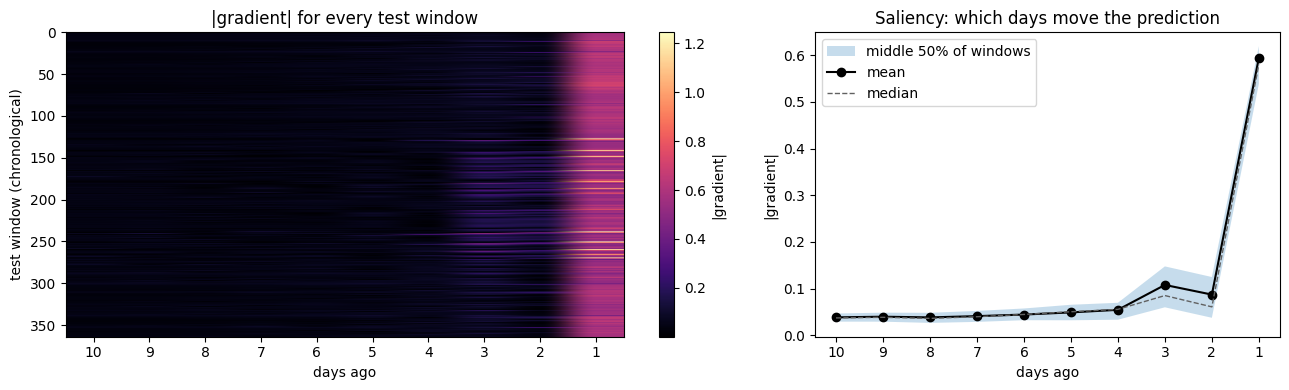

yesterday is the single most influential day in 100% of the 364 test windows
share of total |gradient| carried by yesterday: 54%


In [7]:
A = np.abs(G)

fig, ax = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [1.5, 1]})
im = ax[0].imshow(A, aspect="auto", cmap="magma", extent=[10.5, 0.5, len(A), 0])
ax[0].set_xticks(days_ago); ax[0].set_xlabel("days ago"); ax[0].set_ylabel("test window (chronological)")
ax[0].set_title("|gradient| for every test window")
fig.colorbar(im, ax=ax[0], label="|gradient|")

lo, mid, hi = np.percentile(A, [25, 50, 75], axis=0)
ax[1].fill_between(days_ago, lo, hi, alpha=0.25, label="middle 50% of windows")
ax[1].plot(days_ago, A.mean(axis=0), marker="o", color="black", label="mean")
ax[1].plot(days_ago, mid, ls="--", lw=1, color="#616161", label="median")
ax[1].invert_xaxis(); ax[1].set_xticks(days_ago); ax[1].set_xlabel("days ago")
ax[1].set_ylabel("|gradient|"); ax[1].set_title("Saliency: which days move the prediction"); ax[1].legend()
plt.tight_layout(); plt.show()

wins = (A.argmax(axis=1) == n_steps - 1).mean()
print(f"yesterday is the single most influential day in {wins:.0%} of the {len(A)} test windows")
print(f"share of total |gradient| carried by yesterday: {A[:, -1].sum() / A.sum():.0%}")

## What to remember

- **Occlusion hides a day; saliency nudges it.** Same question, and on this model the same answer.
- **Saliency is cheap** - one backward pass for every day of every window, instead of one re-scoring per day. That
  is why it is the method people reach for on large models.
- **It is a local approximation.** Panel B is how you find out whether "local" was good enough. Check it once on a
  model you understand, the way we just did, before you trust it on one you don't.
- **Absolute values for ranking, signed values for reading one case.** Averaging signed gradients across windows
  cancels out and tells you almost nothing.

Next, on a model with five features instead of one: **`Explaining_an_LSTM`** - permutation importance, occlusion by
time step, saliency as a sensors × minutes grid, integrated gradients, what-if, and SHAP.